# A meshing tutorial that uses gmsh 

In this notebook, we show an example on how to build a triangular mesh for a vertical fault using [gmsh](https://gmsh.info/). We will show how to create patches of varying sizes with respect to depth and along the fault, based on user-defined functions.

## Python imports

In [1]:
# Some imports
import cmcrameri.cm as cmc
import numpy as np
from scipy.spatial import KDTree

# Import csi
import csi

# Some plotting imports
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cmx

# gmsh
import gmsh

# F*** off warnings
import warnings
warnings.simplefilter("ignore") 

# Some styling changes
from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

## General setting

We set the reference point for the custom UTM zone.

In [2]:
lon0 = 39.
lat0 = 39.

## Making the main csi fault object

In this section, we create the main csi Fault object that we will use to build the mesh.

---------------------------------
---------------------------------
Initializing fault EAF


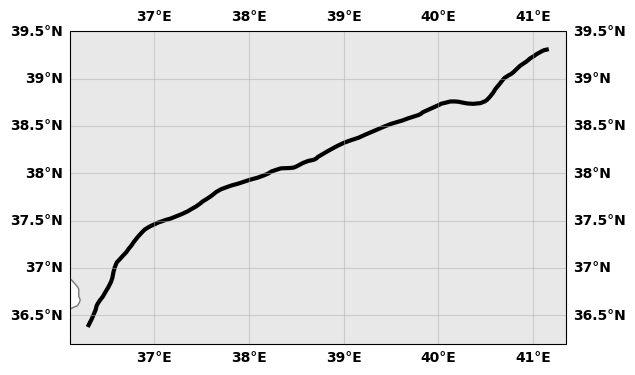

In [3]:
# Initialize csi object
faultEAF = csi.TriangularPatches('EAF', lon0=lon0, lat0=lat0)

# Read the fault trace from a file
faultEAF.file2trace("DataAndModels/tutoFaultMeshing/EAF.xy")

# Discretize the fault trace every kilometer
faultEAF.discretize(every=1.)

# Smooth the fault trace
faultEAF.smoothTrace(discretized=True)

# # Compute the cumulative distance along the fault trace
faultEAF.cumdistance(discretized=True)

# For later plotting
faultEAF.color = 'k'
faultEAF.linewidth = 3

# Plot the fault trace
faultEAF.plot(Fault=False)

## Define the mesh size

In [4]:
# These are the bounds of the box within which we will mesh the fault
depth_min = 0. # km
depth_max = 20. # km

In [5]:
# Stuff to speed up things for computing the distance along the fault trace
_fault_tree = KDTree(np.column_stack([faultEAF.xi, faultEAF.yi]))
_fault_cumdis = faultEAF.cumdistance(discretized=True)

In [6]:
# Global mesh size function
# It calls a user-defined function meshsize_fault_depthdistance
# which computes the mesh size based on depth and distance along the fault

def meshsize_fault_xyz(
    x, y, z,
    fault,
    f_meshsize_depthdistance,
):
    """
    Compute the mesh size at a given point (x, y, z) based on its depth and distance along the fault.

    Parameters
    ----------
    x : float or array-like of x-values
    y : float or array-like of y-values
    z : float or array-like of depth values along the fault
    fault : csi.TriangularPatches object representing the fault
    f_meshsize_depthdistance : callable
        A function that takes (depth, distance_along_fault) and returns the mesh size.
    """
    
    # Checks
    if np.isscalar(x):
        x = np.array([x])
    if np.isscalar(y):
        y = np.array([y])
    if np.isscalar(z):
        z = np.array([z])
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    
    # Compute the distance and depth along the fault for each (x, y, z) point
    _, idx = _fault_tree.query(np.column_stack([x, y]))
    dist = _fault_cumdis[idx]
    depth = z
    
    # Compute the mesh size using the provided function
    return f_meshsize_depthdistance(depth, dist)

In [7]:
# We define a simple function that computes the mesh size based on depth and distance along the fault

def f_meshsize_depthdistance(depth, distance):
    """
    Compute the mesh size based on depth and distance along the fault.

    Parameters
    ----------
    depth : float or array-like
        Depth values (km).
    distance : float or array-like
        Distance along the fault (km).

    Returns
    -------
    mesh_size : float or ndarray
        Computed mesh size (km).
    """
    
    # Simple power-law based on depth
    mesh_size = 2 + 8 * (depth / depth_max) ** 2
    
    # Now we add a dependance on the distance along the fault, to have a finer mesh at the center of the fault and coarser at the edges
    half_length = faultEAF.cumdis.max() / 2
    dist_from_center = np.abs(distance - half_length) / half_length
    mesh_size *= 1 + 2 * dist_from_center ** 2
    
    return mesh_size 

# We build the main mesh size function that takes (x, y, z) and returns the mesh size, that will provide to gmsh
f_meshsize= lambda x, y, z: meshsize_fault_xyz(
    x=x, y=y, z=z,
    fault=faultEAF,
    f_meshsize_depthdistance=f_meshsize_depthdistance
)

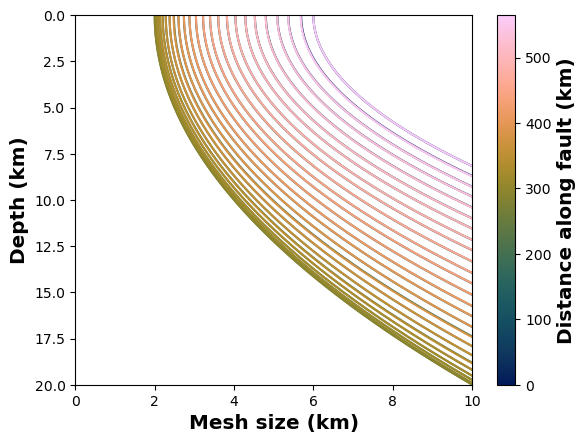

In [8]:
# We show the mesh size function in a plot

fig, ax = plt.subplots()

ax.set_ylabel('Depth (km)')
ax.set_ylim(depth_max, 0)
ax.set_xlabel('Mesh size (km)')
ax.set_xlim(0, 10)

cmap = cmc.batlow
norm = mcolors.Normalize(vmin=0, vmax=faultEAF.cumdis.max())
scalarMap = cmx.ScalarMappable(norm=norm, cmap=cmap)
plt.colorbar(scalarMap, ax=ax, label='Distance along fault (km)')

dist = np.linspace(0, faultEAF.cumdis.max(), 50)
x, y = np.hsplit(np.array([faultEAF.cumdis2xy(d, discretized=True, mode='xy') for d in dist]), 2)
x = x.flatten()
y = y.flatten()
z = np.arange(depth_min, depth_max, .01)

for x_, y_, d_ in zip(x, y, dist):
    ax.plot(f_meshsize(x_, y_, z), z, color=scalarMap.to_rgba(d_))

plt.show(fig)

## Build the mesh using gmsh

In [9]:
# Before using any functions in the Python API, Gmsh must be initialized:
gmsh.initialize()

# Next we add a new model named "EAF":
gmsh.model.add("EAF")

# Creates points for the fault trace at the surface
pts = []
coords = []
lc = 2 # It is not important to set a mesh size at the points, since we will use a mesh size callback,
# but it is required to set some value (it cannot be zero or negative)

for xi, yi in zip(faultEAF.xi, faultEAF.yi):
    pts.append(gmsh.model.geo.addPoint(xi, yi, depth_min, lc))
    coords.append((xi, yi, depth_min))

# Create a spline through the points
spline = gmsh.model.geo.addSpline(pts)

# Create start and end points at depth
x0, y0, _ = coords[0]
x1, y1, _ = coords[-1]
p_start_down = gmsh.model.geo.addPoint(x0, y0, depth_max, lc)
p_end_down = gmsh.model.geo.addPoint(x1, y1, depth_max, lc)

# You could also connect sides manually, but instead: just extrude
gmsh.model.geo.synchronize()

# Extrude the spline to create the vertical surface
extruded = gmsh.model.geo.extrude([(1, spline)], 0, 0, depth_max-depth_min)

# Synchronize
gmsh.model.geo.synchronize()

# The API also allows to set a global mesh size callback, which is called each
# time the mesh size is queried
meshSizeCallback = lambda dim, tag, x, y, z, lc: f_meshsize(x, y, z)
gmsh.model.mesh.setSizeCallback(meshSizeCallback)

# It is better to set these options for a mesh size field
gmsh.option.setNumber("Mesh.MeshSizeExtendFromBoundary", 0)
gmsh.option.setNumber("Mesh.MeshSizeFromPoints", 0)
gmsh.option.setNumber("Mesh.MeshSizeFromCurvature", 0)

# Mesh
gmsh.option.setNumber("Mesh.Algorithm", 6)
gmsh.model.mesh.generate(2)

# Show the mesh
# gmsh.fltk.run()

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Nurb)
Info    : [ 30%] Meshing curve 2 (Nurb)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 2.74218s, CPU 2.65493s)
Info    : Meshing 2D...
Info    : Meshing surface 5 (Surface, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0393971s, CPU 0.038327s)
Info    : 1966 nodes 2794 elements


In [10]:
# Count the number of triangles
# Loop over element types and count triangles
element_types, element_tags, node_tags = gmsh.model.mesh.getElements(2)
for etype, elements in zip(element_types, element_tags):
    if etype == 2:
        print(f"Number of triangles: {len(elements)}")
        break

Number of triangles: 1414


## Convert the mesh to csi format

In [11]:
# Save the triangles
node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
node_coords = np.array(node_coords).reshape((-1, 3))

types, _, node_tags_per_elem = gmsh.model.mesh.getElements()

triangles = []

for etype, elem_nodes in zip(types, node_tags_per_elem):
    if gmsh.model.mesh.getElementProperties(etype)[0] == "Triangle 3":
        # Gmsh gives a flat list, group by 3
        n = 3
        triangles = [elem_nodes[i:i+n] for i in range(0, len(elem_nodes), n)]
        break  # only need triangles

triangles = np.array(triangles) - 1

In [12]:
# Now we have the mesh, we can populate the fault with triangle patches
faultEAF.patch = [np.array([node_coords[t, :] for t in tri]) for tri in triangles]

# Convert the patch vertices to lonlat
faultEAF.patch2ll()

# # Now we have the mesh, we can populate the fault with triangle vertices
# faultEAF.Vertices = node_coords

# # Pass the vertices from utm to lonlat
# faultEAF.vertices2ll()

# # We set the faces of the fault to be the triangles
# faultEAF.Faces = triangles

# Now we have the mesh, we can populate the fault with triangle vertices
faultEAF.setVerticesFromPatches()

# Set the tents
# faultEAF.vertices2tents()

# We check the depth
faultEAF.setdepth()

# We enforce the strike to be consistent along strike (we enforce circulation of the vertices of each triangle to be clockwise)
faultEAF.homogeneizeStrike(direction=0, sign=-1.) # Force the normal to point toward the north

# For plotting purposes we set the slip to be the strike
faultEAF.initializeslip(values='strike')

## Show the mesh

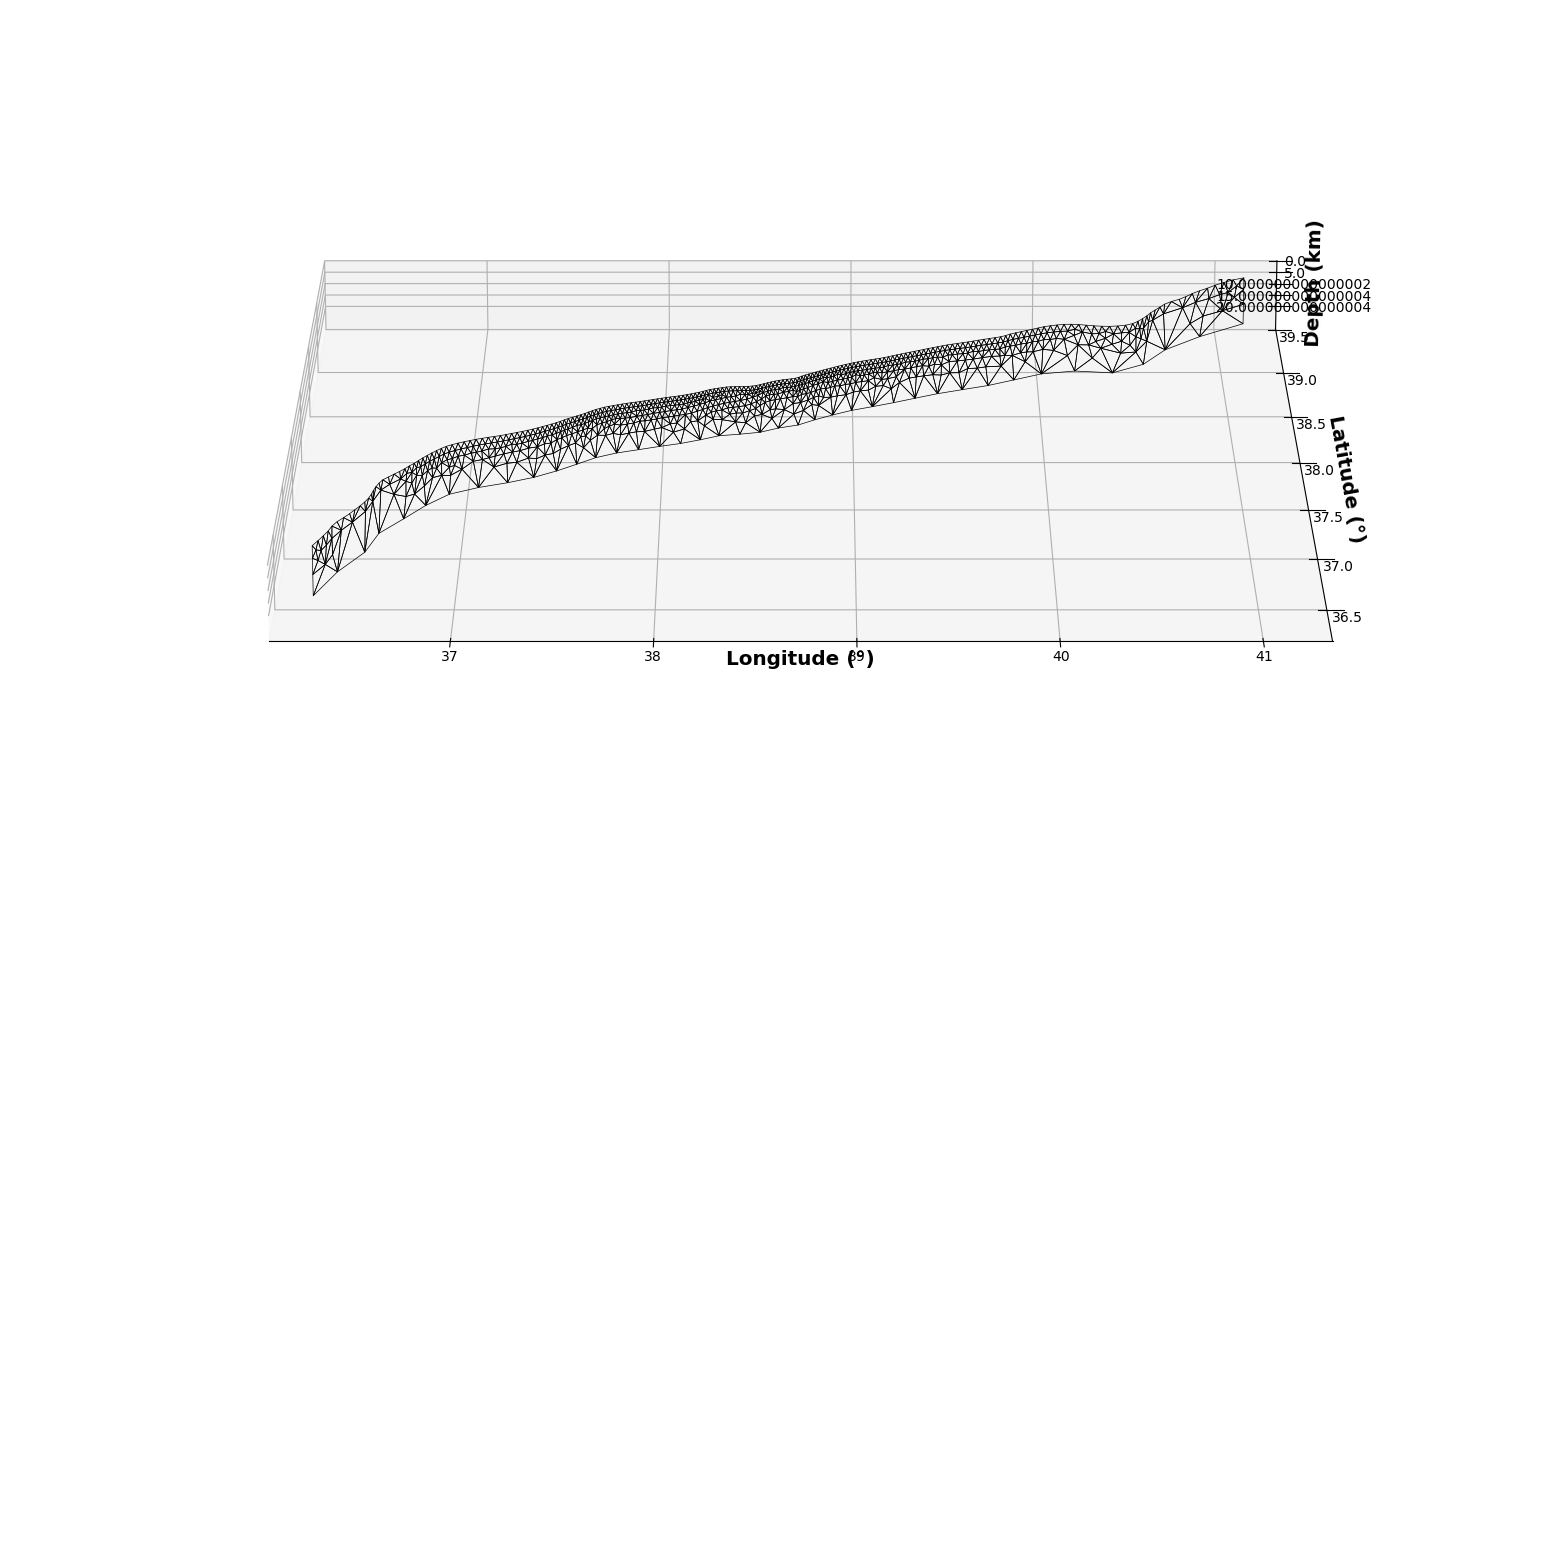

In [13]:
# Show the mesh in 3D
faultEAF.plot(slip='strikeslip', drawCoastlines=True, figsize=((20, 20), None),
               view={'elevation': 20., 'azimuth': 270.}, shape=(1, 1, .1),
               alpha=0, edgecolor='k', elinewidth=.5, colorbar=False, Map=False)

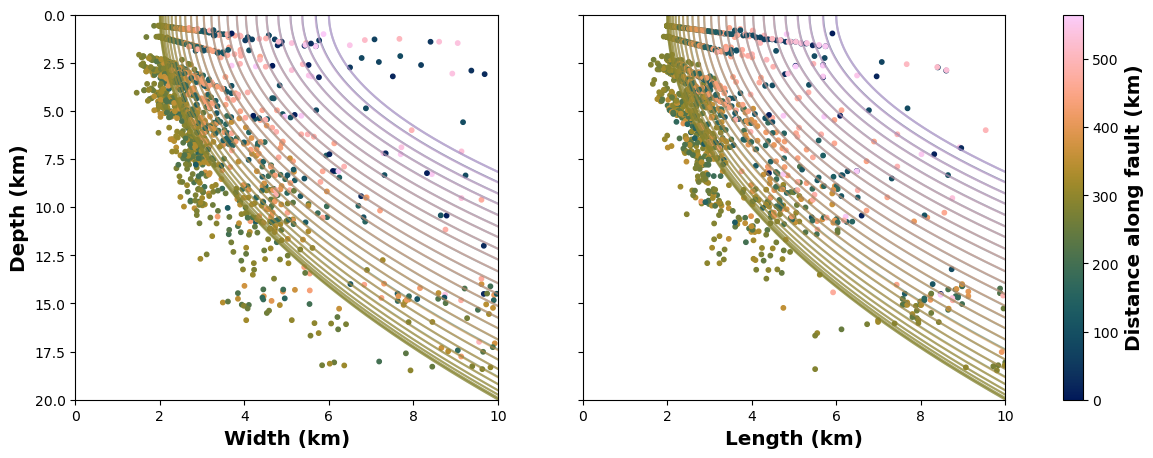

In [14]:
# Show the width and length of the patches

fig, ax = plt.subplots(figsize=(15, 5), ncols=2, sharex=True, sharey=True)

ax[0].set_ylabel('Depth (km)')
ax[0].set_ylim(depth_max, 0)
ax[0].set_xlabel('Width (km)')
ax[0].set_xlim(0, 10)
ax[1].set_xlabel('Length (km)')

cmap = cmc.batlow
norm = mcolors.Normalize(vmin=0, vmax=faultEAF.cumdis.max())
scalarMap = cmx.ScalarMappable(norm=norm, cmap=cmap)
cb = plt.colorbar(scalarMap, ax=ax, label='Distance along fault (km)')

# Extract size of patches
z, w, l, a, d = [], [], [], [], []
for p in faultEAF.patch:
    xc, yc, zc, width, length, strike, dip = faultEAF.getpatchgeometry(p)
    d.append(faultEAF.distance2trace(lon=xc, lat=yc, discretized=True, coord='xy')[0])
    z.append(zc)
    w.append(width)
    l.append(length)

ax[0].scatter(w, z, s=10, c=scalarMap.to_rgba(d))
ax[1].scatter(l, z, s=10, c=scalarMap.to_rgba(d))

# Theoretical size
dist = np.linspace(0, faultEAF.cumdis.max(), 50)
x, y = np.hsplit(np.array([faultEAF.cumdis2xy(d, discretized=True, mode='xy') for d in dist]), 2)
x = x.flatten()
y = y.flatten()
z = np.arange(depth_min, depth_max, .01)
for x_, y_, d_ in zip(x, y, dist):
    ax[0].plot(f_meshsize(x_, y_, z), z, color=scalarMap.to_rgba(d_), alpha=0.5)
    ax[1].plot(f_meshsize(x_, y_, z), z, color=scalarMap.to_rgba(d_), alpha=0.5)
    
plt.show(fig)

## Save

In [15]:
# You can save using csi format (useful for later use)
# faultEAF.writePatches2File("/mesh_fault_EAF.txt")

# Save the mesh in gmsh format
# gmsh.write("mesh_fault_EAF.msh")

In [16]:
# Close Gmsh
gmsh.finalize()

That's all folks! Now you can experiment with the function to adjust the mesh size to your needs, change the gmsh algorithms...